# Steam Games Data Analysis & Rating Prediction
## Objective

This project analyzes a Steam games dataset to understand how game price, genre, release timing, discounts, and review activity relate to game quality and popularity.

The project focuses on:

- **Exploratory Data Analysis (EDA):** Understanding the structure, trends, and distribution of key game attributes.
- **Feature Engineering:** Creating useful variables from raw release and review data.
- **Classification:** Building a simple machine learning model to predict whether a game is highly rated.

In [1]:
# Import Path from pathlib so the notebook can build file paths in a clean, cross-platform way.
from pathlib import Path  # Used for portable path handling instead of hardcoding OS-specific separators.

# Import NumPy for fast numerical operations and array-based calculations.
import numpy as np  # Common library for mathematical functions and vectorized operations.

# Import Pandas for working with tabular data in DataFrame form.
import pandas as pd  # Core library for data loading, cleaning, transformation, and analysis.

# Import Matplotlib's pyplot interface for creating static plots.
import matplotlib.pyplot as plt  # Main plotting interface used to build and customize charts.

# Import Seaborn for statistical visualizations with cleaner defaults.
import seaborn as sns  # Higher-level plotting library built on top of Matplotlib.

# Import display so DataFrames can be shown nicely in Jupyter notebooks.
from IPython.display import display  # Enables rich output rendering inside notebooks.

# Import train_test_split to separate data into training and testing subsets.
from sklearn.model_selection import train_test_split  # Helps evaluate models on unseen data.

# Import Pipeline to chain preprocessing and modeling steps together.
from sklearn.pipeline import Pipeline  # Keeps preprocessing and modeling organized as one workflow.

# Import StandardScaler to normalize numeric features before logistic regression.
from sklearn.preprocessing import StandardScaler  # Scales features to similar ranges for better model stability.

# Import LogisticRegression as the main supervised classification model.
from sklearn.linear_model import LogisticRegression  # Linear classifier commonly used for binary prediction tasks.

# Import DummyClassifier as a simple baseline model for comparison.
from sklearn.dummy import DummyClassifier  # Baseline that predicts a simple rule to measure model usefulness.

# Import evaluation metrics and plot helper for model assessment.
from sklearn.metrics import (  # Grouped import for cleaner metric and visualization access.
    accuracy_score,  # Measures the fraction of correct predictions.
    balanced_accuracy_score,  # Adjusts accuracy for class imbalance by averaging recall across classes.
    classification_report,  # Produces precision, recall, F1-score, and support per class.
    ConfusionMatrixDisplay  # Visual helper to plot the confusion matrix.
)

# Set a consistent Seaborn theme for cleaner and more readable charts.
sns.set_theme(style="whitegrid", context="notebook")  # White grid improves readability in analysis plots.

# Set default figure width and height for all Matplotlib charts.
plt.rcParams["figure.figsize"] = (12, 4)  # Makes plots wide enough for labels and comparisons.

# Set default DPI so plots appear sharper in notebook output.
plt.rcParams["figure.dpi"] = 120  # Improves chart clarity on screen.

---

## 1. Load the Dataset

The dataset is loaded using a portable file path so the notebook works in different environments.

If the CSV file is stored inside a `data` folder, the notebook will use that path first.

In [2]:
# Define possible file locations to make the notebook portable
candidate_paths = [  # List of places where the dataset may exist.
    Path("data/steam_games_2026.csv"),  # Preferred location inside a 'data' folder.
    Path("steam_games_2026.csv"),       # Alternative: same directory as notebook/script.
]

# Loop through paths to find where the dataset exists
for path in candidate_paths:  # Check each candidate path one by one.
    if path.exists():  # Check if file exists at current path.
        data_path = path  # Store the first valid file path found.
        break  # Exit the loop once the file is found.
else:  # This block runs only if no break occurred in the loop.
    # If file is not found in any of the candidate paths, raise an error
    raise FileNotFoundError(  # Stop execution with a clear message when the file is missing.
        "Could not find steam_games_2026.csv. Put it in the current folder or in a data/ folder."
    )

# Load dataset into a Pandas DataFrame
df = pd.read_csv(data_path, index_col="AppID")  # Reads CSV into a DataFrame and uses AppID as the row index.
# Reads CSV file into structured table format for analysis  # Clarifies that the file is now in tabular form.

# Convert Release_Date properly
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")  # Converts text dates to datetime; invalid values become NaT.

---

## 2. Basic Data Understanding

Before moving into analysis, it is important to inspect the dataset structure, data types, missing values, and summary statistics.

These checks help confirm that the data is usable and ready for feature engineering.

In [3]:
# Display the first few rows to understand the dataset structure
display(df.head())  # Shows the top rows so we can inspect columns and sample values.

,Name,Release_Date,Primary_Genre,All_Tags,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Steam_Deck_Status,Estimated_Owners,24h_Peak_Players
AppID,,,,,,,,,,,
730,Counter-Strike 2,2012-08-21,Action,FPS;Shooter;Multiplayer;Competitive;Action;Tea...,0.00,0,83,4980365,Unknown,149410950,1013936
2868840,Slay the Spire 2,2026-03-05,Indie,Strategy;Roguelike;Card Game;Deckbuilding;Co-o...,24.99,0,97,49549,Unknown,1486470,0
3321460,Crimson Desert,2026-03-19,Action,Action;Open World;Singleplayer;Adventure;Comba...,69.99,0,0,0,Unknown,0,0
3065800,Marathon,2026-03-05,Action,Extraction Shooter;PvP;Multiplayer;Sci-fi;Shoo...,39.99,0,90,24360,Unknown,730800,0
3764200,Resident Evil Requiem,2026-02-26,Action,Survival Horror;Zombies;Horror;Third-Person Sh...,69.99,0,96,79667,Unknown,2390010,0


In [4]:
# Show the shape of the dataset
print(f"Shape: {df.shape}")  # Prints rows and columns to understand dataset size.

Shape: (1000, 11)


In [35]:
# Display the list of columns
display(df.columns)  # Shows all column names for quick schema inspection.

['Name', 'Release_Date', 'Primary_Genre', 'All_Tags', 'Price_USD', 'Discount_Pct', 'Review_Score_Pct', 'Total_Reviews', 'Steam_Deck_Status', 'Estimated_Owners', '24h_Peak_Players', 'Release_Year', 'Release_Month', 'is_high_rated', 'price_category', 'popularity', 'has_discount', 'log_reviews']


In [6]:
# Show data types and non-null counts
df.info()  # Displays column types, missing counts, and memory usage.

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 730 to 917950
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Name               1000 non-null   object        
 1   Release_Date       998 non-null    datetime64[ns]
 2   Primary_Genre      1000 non-null   object        
 3   All_Tags           986 non-null    object        
 4   Price_USD          1000 non-null   float64       
 5   Discount_Pct       1000 non-null   int64         
 6   Review_Score_Pct   1000 non-null   int64         
 7   Total_Reviews      1000 non-null   int64         
 8   Steam_Deck_Status  1000 non-null   object        
 9   Estimated_Owners   1000 non-null   int64         
 10  24h_Peak_Players   1000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 93.8+ KB


In [7]:
# Summary statistics for numeric columns
display(df.describe())  # Provides summary stats such as mean, min, max, and quartiles.

,Release_Date,Price_USD,Discount_Pct,Review_Score_Pct,Total_Reviews,Estimated_Owners,24h_Peak_Players
count,998,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,2021-10-26 13:45:19.839679232,21.992930,18.145000,79.658000,6.387119e+04,1.916136e+06,5.213243e+03
min,2006-11-29 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,2019-01-25 18:00:00,7.790000,0.000000,75.000000,1.638250e+03,4.914750e+04,0.000000e+00
50%,2023-04-06 00:00:00,19.790000,0.000000,85.000000,1.173200e+04,3.519600e+05,2.865000e+02
75%,2025-05-07 18:00:00,29.990000,35.000000,92.000000,4.851575e+04,1.455472e+06,1.601000e+03
max,2026-07-09 00:00:00,69.990000,95.000000,100.000000,4.980365e+06,1.494110e+08,1.013936e+06
std,NaN,18.812135,28.613716,19.382227,2.115879e+05,6.347638e+06,4.037537e+04


In [8]:
# Check missing values in each column
display(df.isna().sum().sort_values(ascending=False))  # Counts missing values and sorts from most to least missing.

All_Tags             14
Release_Date          2
Name                  0
Primary_Genre         0
Price_USD             0
Discount_Pct          0
Review_Score_Pct      0
Total_Reviews         0
Steam_Deck_Status     0
Estimated_Owners      0
24h_Peak_Players      0
dtype: int64

In [9]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())  # Counts fully duplicated rows in the dataset.

Duplicate rows: 0


---

## 3. Data Cleaning and Feature Engineering

The raw dataset contains useful information, but it needs a few transformations before analysis and modeling.

From the original columns, we create new features such as:

- `Release_Year` for trend analysis
- `Release_Month` for seasonal patterns
- `is_high_rated` as the target variable
- `price_category` to group games by price
- `has_discount` to capture promotional pricing
- `log_reviews` to reduce the skew in total reviews

In [10]:
# Fill missing tags with the primary genre so the text field remains usable
df["All_Tags"] = df["All_Tags"].fillna(df["Primary_Genre"])  # Uses a related categorical field to reduce missing text data.

In [11]:
# Drop rows where release date is missing because time-based analysis needs valid dates
df = df.dropna(subset=["Release_Date"]).copy()  # Removes rows without dates and creates a safe independent copy.

In [12]:
# Remove duplicate rows if any exist
df = df.drop_duplicates().copy()  # Ensures each row is unique before analysis and modeling.

In [13]:
# Create time-based features
df["Release_Year"] = df["Release_Date"].dt.year  # Extracts the year from the release date for trend analysis.
df["Release_Month"] = df["Release_Date"].dt.month  # Extracts the month for seasonal release patterns.

# Create target column:
# 1 = high rated game, 0 = lower rated game
df['is_high_rated'] = df['Review_Score_Pct'].apply(lambda x: 1 if x >= 80 else 0)  # Converts review score into a binary classification target.

# Group games into price categories
df["price_category"] = df["Price_USD"].apply(  # Creates a readable price bucket from numeric prices.
    lambda price: "Free" if price == 0 else  # Labels zero-priced games as Free.
    "Low" if price < 10 else  # Labels inexpensive games as Low.
    "Medium" if price < 30 else  # Labels mid-priced games as Medium.
    "High"  # Labels expensive games as High.
)

# Popularity bucket based on total reviews
df["popularity"] = pd.qcut(  # Splits the review count into equal-sized quantile groups.
    df["Total_Reviews"],  # Uses total review count as the ranking variable.
    q=3,  # Divides the data into three buckets.
    labels=["Low", "Medium", "High"]  # Assigns human-readable labels to the quantiles.
)

# Flag whether a game has any discount
df["has_discount"] = df["Discount_Pct"].apply(lambda x: 1 if x > 0 else 0)  # Creates a binary feature indicating discount presence.

# Use a log transform because review counts are heavily skewed
df["log_reviews"] = np.log1p(df["Total_Reviews"])  # Applies log(1 + x) to compress large review counts safely.

In [14]:
# Quick preview of the engineered columns
display(  # Displays a compact preview of important engineered features.
    df[  # Selects a subset of columns to verify feature engineering.
        [  # Explicit list of columns to inspect.
            "Name",  # Game name for identification.
            "Primary_Genre",  # Main genre for categorical context.
            "Price_USD",  # Raw price feature.
            "Review_Score_Pct",  # Original rating percentage.
            "Release_Year",  # Engineered time feature.
            "is_high_rated",  # Binary target label.
            "price_category",  # Binned price feature.
            "popularity",  # Review-based quantile bucket.
            "has_discount",  # Discount indicator feature.
            "log_reviews"  # Transformed review-count feature.
        ]
    ].head()  # Shows only the first few rows for a quick sanity check.
)

,Name,Primary_Genre,Price_USD,Review_Score_Pct,Release_Year,is_high_rated,price_category,popularity,has_discount,log_reviews
AppID,,,,,,,,,,
730,Counter-Strike 2,Action,0.00,83,2012,1,Free,High,0,15.421014
2868840,Slay the Spire 2,Indie,24.99,97,2026,1,Medium,High,0,10.810738
3321460,Crimson Desert,Action,69.99,0,2026,0,High,Low,0,0.000000
3065800,Marathon,Action,39.99,90,2026,1,High,Medium,0,10.100739
3764200,Resident Evil Requiem,Action,69.99,96,2026,1,High,High,0,11.285623


---

## 4. Correlation Heatmap

This heatmap helps identify relationships between the numeric variables in the dataset.

It is useful for checking whether price, reviews, ownership estimates, and peak players move together in a meaningful way.

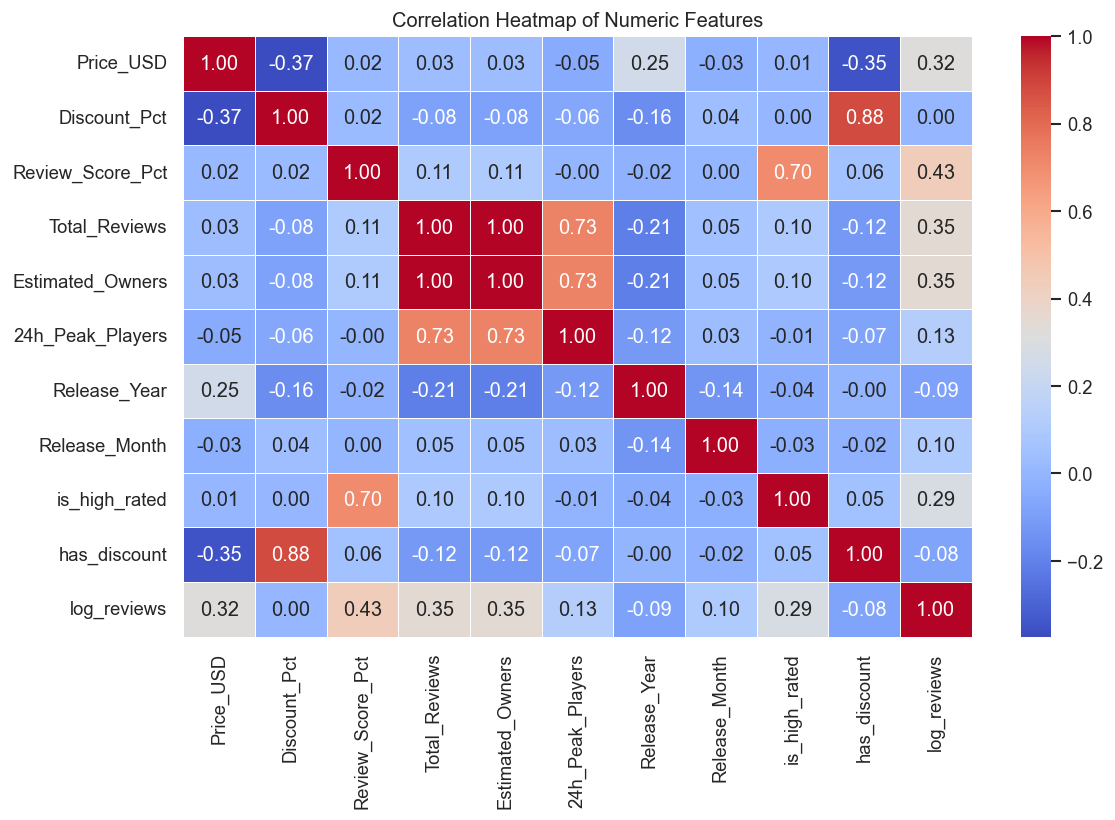

In [15]:
corr_matrix = df.corr(numeric_only=True)  # Calculates correlations only for numeric columns.

# Plot the heatmap
plt.figure(figsize=(10, 7))  # Creates a figure sized for a readable correlation plot.
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)  # Shows pairwise correlations with annotated values.
plt.title("Correlation Heatmap of Numeric Features")  # Adds a clear chart title.
plt.tight_layout()  # Adjusts spacing so labels do not overlap.
plt.show()  # Renders the heatmap to the notebook.

### Interpretation
- Strong positive relationships suggest variables that tend to increase together, such as review count and player activity.
- Weak or near-zero correlations indicate that some game attributes do not move closely together.
- Price often remains only loosely connected with review score, which suggests that cost alone does not define perceived quality.
- This helps narrow down which features are worth using later in modeling.

---

## 5. Distribution of Game Prices

A price distribution helps reveal how Steam games are positioned across free, budget, and premium pricing levels.

A histogram is the right choice here because price is a continuous variable.

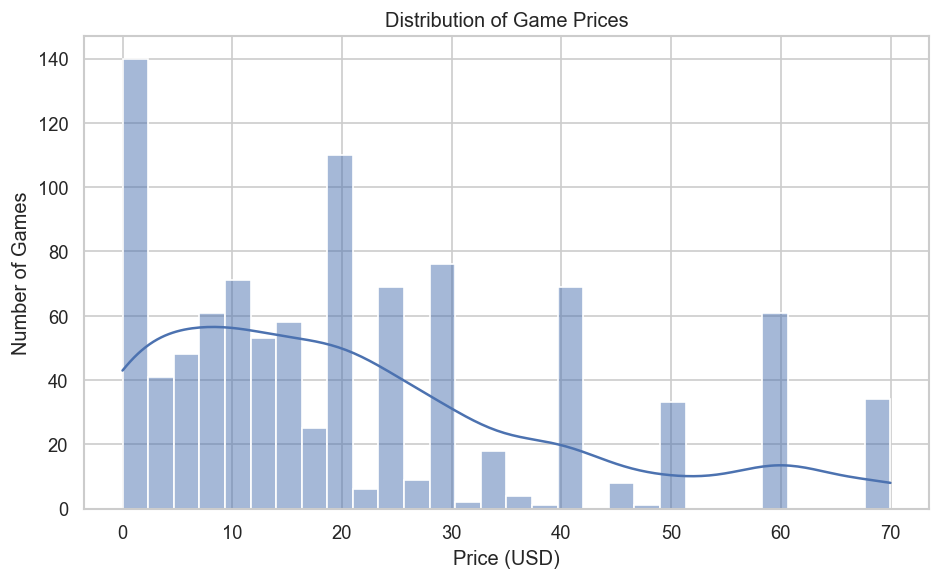

In [16]:
# Plot the distribution of game prices
plt.figure(figsize=(8, 5))  # Creates a figure sized for a distribution plot.
sns.histplot(data=df, x="Price_USD", bins=30, kde=True)  # Histogram plus KDE to show shape and smooth density.
plt.title("Distribution of Game Prices")  # Labels the chart for interpretation.
plt.xlabel("Price (USD)")  # Names the x-axis using the actual unit.
plt.ylabel("Number of Games")  # Names the y-axis as frequency/count.
plt.tight_layout()  # Prevents overlap among labels and plot elements.
plt.show()  # Displays the price distribution.

### Interpretation
- The distribution is usually concentrated in the lower price range, which suggests that affordable games make up a large part of the platform.
- A long right tail indicates that premium-priced games exist, but they are a smaller share of the market.
- This pattern is useful for understanding how Steam balances volume with higher-value titles.

---

## 6. Distribution of Review Scores

Review score distribution gives a quick view of how the dataset is perceived by players.

This chart helps identify whether the library leans toward strongly positive games or contains a wider spread of quality.

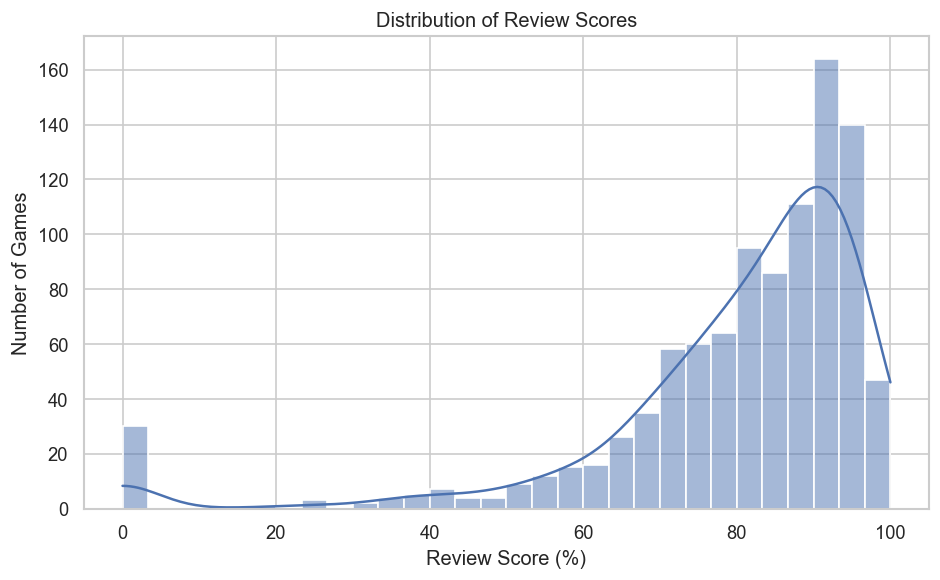

In [17]:
# Plot the distribution of review scores
plt.figure(figsize=(8, 5))  # Sets a consistent figure size for comparison.
sns.histplot(data=df, x="Review_Score_Pct", bins=30, kde=True)  # Shows how review scores are spread across games.
plt.title("Distribution of Review Scores")  # Explains what the plot is about.
plt.xlabel("Review Score (%)")  # Makes the score scale explicit.
plt.ylabel("Number of Games")  # Indicates how many games fall into each score range.
plt.tight_layout()  # Improves spacing for readability.
plt.show()  # Displays the review score distribution.

### Interpretation
- A concentration in the higher score range suggests that many games in the dataset are rated positively.
- A spread across the full score range indicates that the dataset contains a mix of strong and weak performers.
- This is important because the target variable for classification depends directly on review score.

---

## 7. High-Rated vs Low-Rated Games

This chart compares the two classes used for the machine learning target.

It helps verify whether the dataset is balanced or if one class dominates the prediction problem.

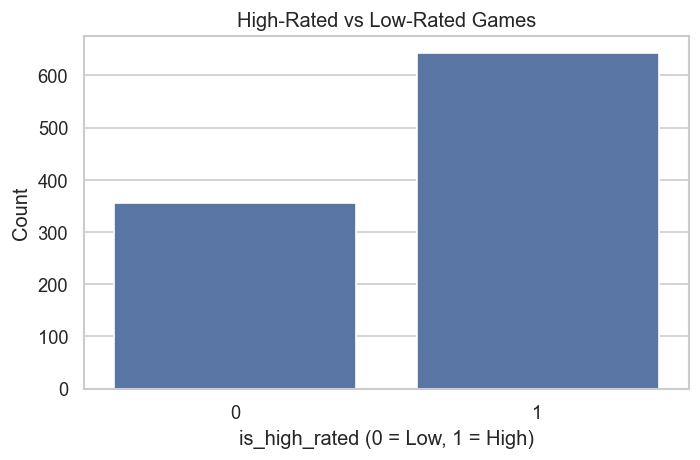

In [18]:
# Plot class balance for the target variable
plt.figure(figsize=(6, 4))  # Uses a smaller figure because the chart has only two categories.
sns.countplot(data=df, x="is_high_rated")  # Counts how many games belong to each class.
plt.title("High-Rated vs Low-Rated Games")  # Describes the binary target distribution.
plt.xlabel("is_high_rated (0 = Low, 1 = High)")  # Clarifies how to interpret class labels.
plt.ylabel("Count")  # Shows the number of games in each class.
plt.tight_layout()  # Keeps the chart compact and readable.
plt.show()  # Displays the class balance chart.

### Interpretation
- A noticeable imbalance between the two bars means the model may be biased toward the larger class.
- If high-rated games dominate, the classification task becomes easier but less informative.
- If both classes are fairly close, the prediction problem is more balanced and evaluation becomes more reliable.

---

## 8. Top 10 Game Genres

Genre analysis helps identify which types of games dominate the dataset.

This is useful for understanding market concentration and the kinds of experiences that appear most often on Steam.

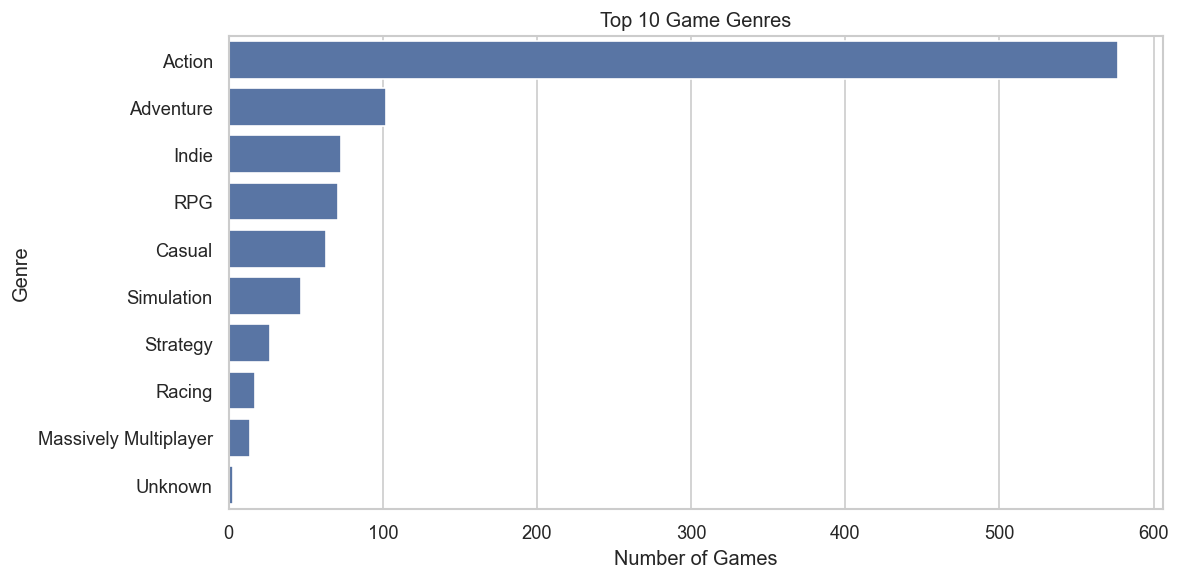

In [19]:
# Identify the top 10 genres
top_genres = df["Primary_Genre"].value_counts().head(10)  # Counts genres and keeps the ten most common.

# Plot the top genres
plt.figure(figsize=(10, 5))  # Creates a wide figure so genre names fit comfortably.
sns.barplot(x=top_genres.values, y=top_genres.index)  # Horizontal bar chart for easier comparison of category counts.
plt.title("Top 10 Game Genres")  # Explains the content of the bar chart.
plt.xlabel("Number of Games")  # Indicates bar length corresponds to count.
plt.ylabel("Genre")  # Shows the genre names on the vertical axis.
plt.tight_layout()  # Prevents labels from getting cut off.
plt.show()  # Displays the genre frequency chart.

### Interpretation
- The most frequent genres represent the strongest content categories in the dataset.
- High concentration in a few genres suggests that Steam has clear genre leaders.
- This insight is valuable for understanding what type of content dominates the market and where player demand may be strongest.

---

## 9. Number of Games Released Over Time

A release trend shows how the platform evolved across different years.

A line plot is a strong choice here because it highlights growth and change over time.

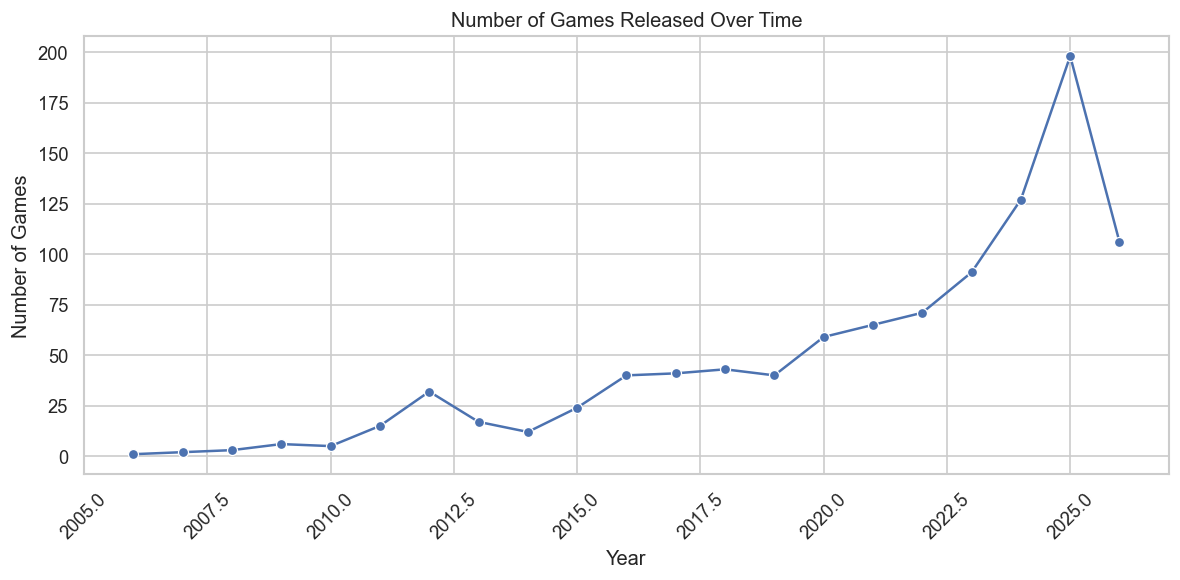

In [20]:
# Count number of games released each year
year_counts = df["Release_Year"].value_counts().sort_index()  # Counts releases per year and sorts chronologically.

# Plot release trend over time
plt.figure(figsize=(10, 5))  # Sets a wide figure suitable for a time trend.
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")  # Line plot highlights changes over time.
plt.title("Number of Games Released Over Time")  # Describes the trend being analyzed.
plt.xlabel("Year")  # Labels the time axis.
plt.ylabel("Number of Games")  # Labels the count axis.
plt.xticks(rotation=45)  # Rotates year labels for better readability.
plt.tight_layout()  # Keeps labels aligned neatly.
plt.show()  # Displays the release trend chart.

### Interpretation
- Rising values over time suggest that the Steam ecosystem has expanded and more games are being published.
- Sudden jumps can reflect periods of rapid market growth or changes in publishing activity.
- This trend helps connect game supply with the broader evolution of the platform.

---

## 10. Price vs Review Score

This chart checks whether higher pricing actually corresponds to better user sentiment.

If the relationship is weak, pricing alone should not be treated as a quality signal.

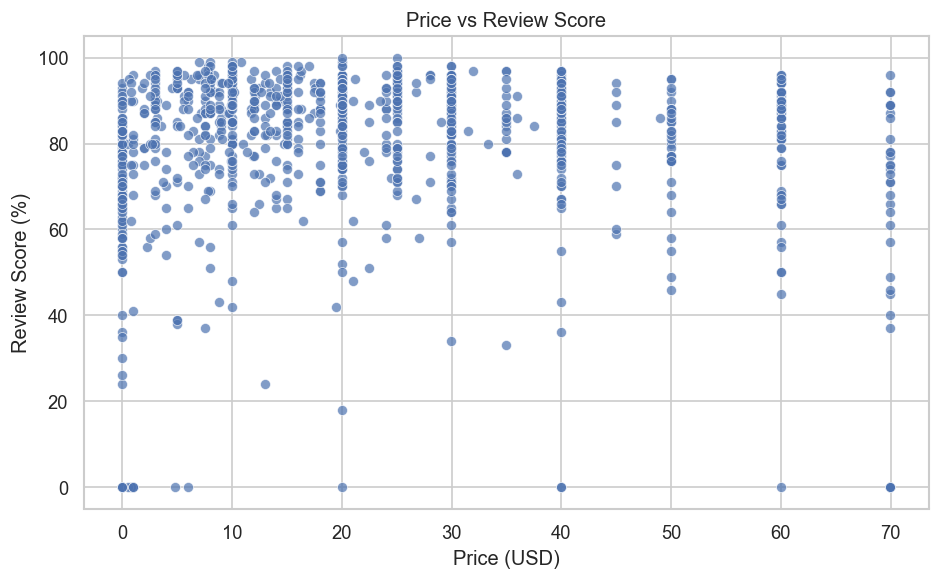

In [21]:
# Plot relationship between price and review score
plt.figure(figsize=(8, 5))  # Creates a moderately sized figure for scatter visualization.
sns.scatterplot(data=df, x="Price_USD", y="Review_Score_Pct", alpha=0.7)  # Scatter plot shows how price relates to rating.
plt.title("Price vs Review Score")  # States the relationship being examined.
plt.xlabel("Price (USD)")  # Labels the price axis.
plt.ylabel("Review Score (%)")  # Labels the rating axis.
plt.tight_layout()  # Prevents overlap and clipping.
plt.show()  # Displays the scatter plot.

### Interpretation
- A scattered pattern with no clear slope suggests that price is not a strong predictor of review score.
- If higher-priced games do not consistently receive higher ratings, quality appears to depend on more than cost.
- This insight matters because pricing strategy alone may not guarantee stronger user feedback.

---

## 11. Discount Distribution

Discounts are a major part of Steam’s pricing strategy, so their distribution is worth checking separately.

This helps explain how frequently games are promoted and whether discounting is common.

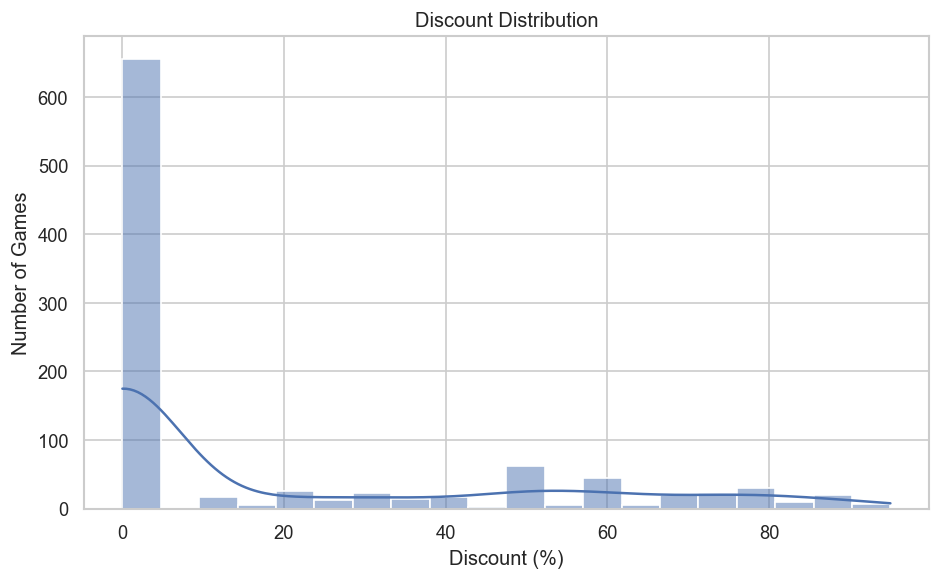

In [22]:
# Plot the distribution of discount percentages
plt.figure(figsize=(8, 5))  # Sets figure size for the discount histogram.
sns.histplot(data=df, x="Discount_Pct", bins=20, kde=True)  # Shows discount frequency and overall shape.
plt.title("Discount Distribution")  # Describes the chart topic.
plt.xlabel("Discount (%)")  # Labels the discount percentage axis.
plt.ylabel("Number of Games")  # Shows counts per bin.
plt.tight_layout()  # Improves spacing for display.
plt.show()  # Displays the discount distribution.

### Interpretation
- A large concentration near zero means many games are sold without a discount at a given moment.
- A meaningful spread toward higher discount values shows that promotions are actively used across the catalog.
- This helps explain how Steam encourages sales and player engagement through pricing strategies.

---

## 12. Top 10 Most Reviewed Games

The most reviewed games usually represent the titles that attracted the strongest attention from players.

Review volume is a good proxy for popularity and community engagement.

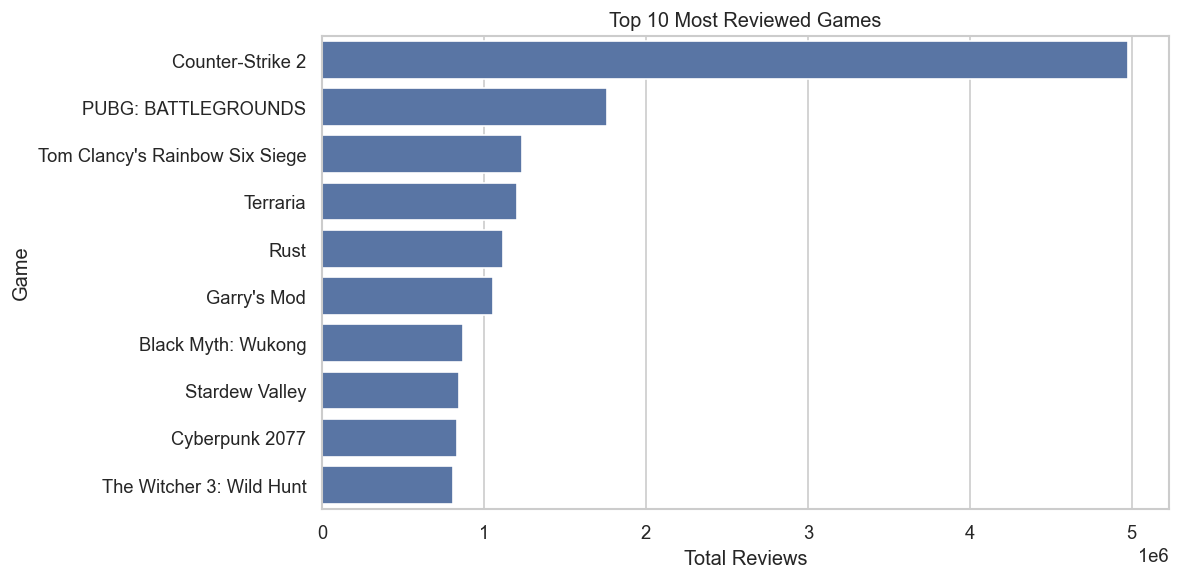

In [23]:
# Identify the top 10 games by total reviews
top_games = df.sort_values(by="Total_Reviews", ascending=False).head(10)  # Sorts by reviews descending to find the most discussed games.

# Plot the most reviewed games
plt.figure(figsize=(10, 5))  # Gives enough room for game names on the axis.
sns.barplot(x=top_games["Total_Reviews"], y=top_games["Name"])  # Horizontal bar chart makes ranked comparisons easy to read.
plt.title("Top 10 Most Reviewed Games")  # States the ranking being visualized.
plt.xlabel("Total Reviews")  # Indicates bar length corresponds to review count.
plt.ylabel("Game")  # Lists game names on the vertical axis.
plt.tight_layout()  # Prevents labels from being clipped.
plt.show()  # Displays the ranking chart.

### Interpretation
- Games with very high review counts usually have strong visibility, broad reach, or long-term player interest.
- A small number of titles often capture a large amount of attention, which reflects the natural popularity concentration in gaming platforms.
- This helps identify the titles that shaped player discussion the most.

---

## Key Insights
- Affordable and mid-priced games make up a large part of the catalog.
- Review scores are generally concentrated in the positive range.
- Genre popularity is uneven, with a few categories appearing more often than others.
- Game releases increase over time, showing platform growth.
- Price alone does not appear to strongly determine review score.
- Discounts are widely used, but not every game is promoted at the same time.
- A small group of games gathers a very large share of total reviews.

---

## Final Conclusion

The Steam dataset shows clear patterns in pricing, genre distribution, release growth, and review behavior.

The strongest takeaway is that popularity and quality are shaped by multiple factors together, not just price. This makes the dataset useful for both business-style analysis and predictive modeling.

---

## 13. Machine Learning Model

In this section, a simple classification model is built to predict whether a game is highly rated using engineered numeric features.

The goal is not to create a perfect model. The goal is to build a clean baseline that shows how much signal is available in the data.

In [24]:
# Define feature columns for the model
features = [  # Selects numeric and engineered predictors likely related to rating.
    "Price_USD",  # Game price may influence perceived value and rating.
    "Discount_Pct",  # Discounts can affect purchase behavior and popularity.
    "Estimated_Owners",  # Ownership is a proxy for market reach and adoption.
    "log_reviews",  # Logged reviews reduce skew and stabilize large counts.
    "24h_Peak_Players",  # Peak player count captures recent engagement.
    "Release_Year",  # Newer or older games may have different rating patterns.
    "has_discount"  # Binary discount flag adds a simple promotional signal.
]

# Create feature matrix and target variable
X = df[features].copy()  # Builds the input feature matrix for modeling.
y = df["is_high_rated"].copy()  # Builds the binary target variable to predict.

# Preview the selected features
display(X.head())  # Shows the first rows of the modeling features for verification.

,Price_USD,Discount_Pct,Estimated_Owners,log_reviews,24h_Peak_Players,Release_Year,has_discount
AppID,,,,,,,
730,0.00,0,149410950,15.421014,1013936,2012,0
2868840,24.99,0,1486470,10.810738,0,2026,0
3321460,69.99,0,0,0.000000,0,2026,0
3065800,39.99,0,730800,10.100739,0,2026,0
3764200,69.99,0,2390010,11.285623,0,2026,0


### Step 1: Train-Test Split

The dataset is split into training and testing sets so the model can be evaluated on unseen data.

Stratification is used to preserve the class balance in both sets.

In [25]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(  # Splits data for honest model evaluation.
    X,  # Feature matrix.
    y,  # Target labels.
    test_size=0.2,  # Reserves 20% of data for testing.
    random_state=42,  # Ensures reproducible splits.
    stratify=y  # Keeps class proportions similar in train and test sets.
)

print("Training set shape:", X_train.shape)  # Prints the training feature dimensions.
print("Testing set shape:", X_test.shape)  # Prints the testing feature dimensions.

Training set shape: (798, 7)
Testing set shape: (200, 7)


### Step 2: Model Selection and Training

Logistic Regression is a good first model because it is simple, fast, and easy to interpret.

A pipeline keeps scaling and modeling together in a clean workflow.

In [26]:
# Build a pipeline with scaling and logistic regression
model = Pipeline(steps=[  # Combines preprocessing and modeling into one workflow.
    ("scaler", StandardScaler()),  # Standardizes numeric features before model fitting.
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))  # Logistic regression model with more iterations for convergence.
])

# Train the model
model.fit(X_train, y_train)  # Fits the scaler and classifier on training data only.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

### Baseline Comparison

A baseline model helps determine whether Logistic Regression is actually learning something useful.

The most frequent class is used as the naive benchmark.

In [27]:
# Create a simple baseline model
baseline = DummyClassifier(strategy="most_frequent")  # Predicts the majority class every time as a benchmark.

In [28]:
# Train the baseline
baseline.fit(X_train, y_train)  # Learns the most frequent class from the training set.

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [29]:
# Predict with the baseline model
baseline_pred = baseline.predict(X_test)  # Generates baseline predictions on the test set.

In [30]:
# Print baseline accuracy
print("Baseline Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))  # Measures how well the trivial model performs.

Baseline Accuracy: 0.645


### Step 3: Predictions and Evaluation

The trained model is now tested on unseen data.

Accuracy, balanced accuracy, and the classification report give a fuller picture of performance.

In [31]:
# Make predictions using the trained model
y_pred = model.predict(X_test)  # Predicts high-rated vs low-rated classes on unseen data.

In [32]:
# Evaluate the model
print("Model Accuracy:", round(accuracy_score(y_test, y_pred), 4))  # Reports overall correctness.
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))  # Reports fairness across classes.
print("\nClassification Report:")  # Adds spacing before the detailed metrics table.
print(classification_report(y_test, y_pred, zero_division=0))  # Prints precision, recall, F1-score, and support with safe zero handling.

Model Accuracy: 0.705
Balanced Accuracy: 0.6098

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.28      0.40        71
           1       0.70      0.94      0.80       129

    accuracy                           0.70       200
   macro avg       0.71      0.61      0.60       200
weighted avg       0.71      0.70      0.66       200



In [33]:
# Show a quick actual vs predicted comparison
results_df = pd.DataFrame({  # Creates a compact comparison table for model output.
    "Actual": y_test.values,  # Stores the true labels from the test set.
    "Predicted": y_pred  # Stores the model's predicted labels.
})

display(results_df.head())  # Shows a few rows to quickly inspect prediction quality.

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,0,1


<Figure size 720x600 with 0 Axes>

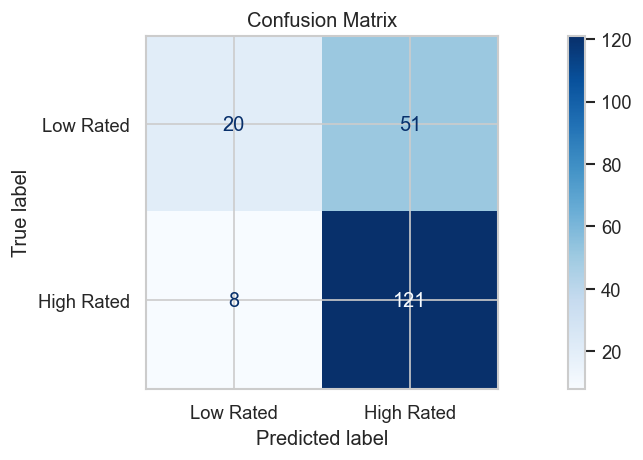

In [34]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))  # Creates a compact figure suited for a 2x2 confusion matrix.
ConfusionMatrixDisplay.from_predictions(  # Builds the confusion matrix directly from true and predicted labels.
    y_test,  # Actual target values.
    y_pred,  # Model predictions.
    display_labels=["Low Rated", "High Rated"],  # Human-friendly labels for the two classes.
    cmap="Blues"  # Blue color scheme improves readability of cell intensity.
)
plt.title("Confusion Matrix")  # Adds a title for interpretation.
plt.tight_layout()  # Ensures the display is neatly arranged.
plt.show()  # Renders the confusion matrix.

## ML Interpretation

The model gives a baseline estimate of how predictable the high-rated label is from basic numeric features.

If performance stays limited, the usual reason is that the current feature set does not capture enough of the underlying quality signal. Review score is often influenced by gameplay, community response, updates, and player sentiment, which are not fully represented here.

---

## Final Model Conclusion

Logistic Regression provides a clean starting point, but it should be treated as a baseline rather than a final solution.

The result suggests that simple pricing and popularity features are not enough to classify game quality with high confidence. A stronger feature set, text-based tag processing, or a more advanced model could improve performance in future work.